<a href="https://colab.research.google.com/github/Rawan806/ML-early-risk-prediction/blob/main/Cardio_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early Cardiovascular Disease Classification Using Machine Learning

## Project Description

This project aims to predict the presence of cardiovascular disease using supervised machine learning techniques. Cardiovascular diseases are among the leading causes of death worldwide, making early detection an important task for improving healthcare outcomes.

The problem is formulated as a binary classification task, where the model predicts whether a patient has cardiovascular disease (1) or not (0).

---

## Dataset

The dataset used in this project is the Cardiovascular Disease dataset, which contains structured patient information collected from medical examinations and lifestyle indicators.

### Key Characteristics:
- Total samples: approximately 70,000 records
- Training set: 56,000 samples
- Testing set: 14,000 samples
- Number of input features: 11
- Target variable: `cardio` (binary)

---

## Input Features

The input consists of 11 structured features describing patient information:

### 1. Demographic Features:
- `age`: Age in days (converted to years during preprocessing)
- `gender`: Encoded gender

### 2. Physical Measurements:
- `height`: Height in centimeters
- `weight`: Weight in kilograms

### 3. Medical Measurements:
- `ap_hi`: Systolic blood pressure
- `ap_lo`: Diastolic blood pressure
- `cholesterol`: Cholesterol level (ordinal)
- `gluc`: Glucose level (ordinal)

### 4. Lifestyle Features:
- `smoke`: Smoking status (0/1)
- `alco`: Alcohol consumption (0/1)
- `active`: Physical activity level (0/1)

The original dataset contains 11 input features. Additional features are later derived during preprocessing.
---

## Output

The target variable is:

- `cardio = 0` → No cardiovascular disease  
- `cardio = 1` → Presence of cardiovascular disease  

---

## Project Structure

This notebook is organized into four main sections:

### Section 1: Data Understanding & Preprocessing
- Data loading and inspection  
- Data cleaning and preparation  
- Exploratory data analysis  

### Section 2: Model Development
- Data splitting  
- Training multiple machine learning models  

### Section 3: Evaluation & Analysis
- Model evaluation using performance metrics  
- Comparison between models  

### Section 4: Optimization & Finalization
- Hyperparameter tuning  
- Model selection and final results  

---

## Objective

The goal of this project is to build a reliable machine learning model that can accurately classify patients based on their risk of cardiovascular disease, using structured clinical and lifestyle data.

# Section 1: Data Understanding & Preprocessing

In this section, we systematically explore and prepare the dataset before applying machine learning models.

We begin by examining the dataset structure and key characteristics, followed by analyzing the target variable and checking for potential data quality issues such as missing values and duplicate records.

Next, we perform data cleaning to ensure consistency, including correcting invalid values and handling outliers.

We then conduct advanced exploratory data analysis (EDA) to investigate the relationships between important features and the target variable, providing insights into factors that may influence cardiovascular disease.

Finally, we apply feature engineering and preprocessing techniques to transform the data into a suitable format for model training in the next stage.

## 1.1 Dataset Overview

In this subsection, we introduce the dataset used in this project and examine its basic structure.

We load the cardiovascular disease dataset from Hugging Face, which is already divided into training and testing splits. We then preview a sample of the data to understand how the features are organized and how each record represents a patient.

This initial overview provides a foundation for the more detailed inspection and preprocessing steps that follow.

In [ ]:
# Install required package
!pip -q install datasets

# Import libraries
import pandas as pd
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset from Hugging Face
ds = load_dataset("e1e1e1/Cardio")

# Convert train and test splits to pandas DataFrames
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

# Preview first rows of training data
print("Training set preview:")
display(df_train.head())

# Preview first rows of testing data
print("Testing set preview:")
display(df_test.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/814 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/701k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/56000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14000 [00:00<?, ? examples/s]

Training set preview:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,23227,1,152,78.0,140,80,1,1,0,0,0,1
1,17464,1,163,55.0,110,70,1,1,1,0,1,0
2,18353,2,165,70.0,110,70,1,1,0,0,1,1
3,19622,1,174,86.0,120,80,1,1,0,0,1,1
4,18886,2,162,65.0,120,80,1,1,0,0,1,0


Testing set preview:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,21141,1,163,63.0,120,80,3,3,0,0,0,1
1,18372,2,166,72.0,110,70,2,2,0,0,1,1
2,22073,1,165,65.0,110,70,3,3,0,0,1,1
3,15334,1,169,68.0,110,80,1,1,0,0,1,0
4,21889,1,165,79.0,120,80,1,1,0,0,0,0


In [ ]:
import os

# Create folders if they don't exist
os.makedirs("outputs/data", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


## 1.2 Initial Data Inspection

In this subsection, we inspect the dataset dimensions, column names, data types, and summary statistics to better understand its structure and feature characteristics.

In [ ]:
# Display dataset dimensions
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# Display column names
print("\nTraining dataset columns:")
print(df_train.columns.tolist())

# Display data types
print("\nData types:")
display(df_train.dtypes)

# Display summary statistics
print("\nSummary statistics:")
display(df_train.describe())

Train shape: (56000, 12)
Test shape: (14000, 12)

Training dataset columns:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data types:


,0
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64
alco,int64



Summary statistics:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,19471.795036,1.350500,164.366304,74.216573,128.613446,96.688339,1.366179,1.226214,0.088518,0.054179,0.802946,0.499268
std,2466.557005,0.477131,8.220743,14.391067,146.234911,196.000378,0.680016,0.571912,0.284049,0.226372,0.397777,0.500004
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17674.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19706.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21332.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,14020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 1.3 Target & Data Quality Check

In this subsection, we analyze the distribution of the target variable and assess the dataset for potential data quality issues such as missing values and duplicate records.

In [ ]:
# Analyze target distribution
print("Target distribution (counts):")
print(df_train["cardio"].value_counts())

print("\nTarget distribution (percentage):")
print((df_train["cardio"].value_counts(normalize=True) * 100).round(2))

# Check for missing values
print("\nMissing values per column:")
display(df_train.isna().sum().sort_values(ascending=False))

# Check for duplicate rows
duplicates = df_train.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

Target distribution (counts):
cardio
0    28041
1    27959
Name: count, dtype: int64

Target distribution (percentage):
cardio
0    50.07
1    49.93
Name: proportion, dtype: float64

Missing values per column:


,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0



Number of duplicate rows: 19


## 1.4 Data Cleaning

In this subsection, we clean the dataset to ensure data quality and consistency. This includes handling duplicate records, correcting invalid values, transforming features, and removing unrealistic outliers.

In [ ]:
# Save shape before full cleaning
before_cleaning = df_train.shape[0]

# ----------------------------
# 1. Remove duplicate rows
# ----------------------------
df_train = df_train.drop_duplicates()

# ----------------------------
# 2. Convert age from days to years
# ----------------------------
df_train["age_years"] = df_train["age"] / 365

# ----------------------------
# 3. Remove invalid blood pressure values
# ----------------------------
df_train = df_train[df_train["ap_hi"] > df_train["ap_lo"]]

# ----------------------------
# 4. Remove extreme outliers
# ----------------------------
df_train = df_train[(df_train["ap_hi"] < 250) & (df_train["ap_lo"] < 200)]

# ----------------------------
# Final shape
# ----------------------------
after_cleaning = df_train.shape[0]

print("Before cleaning:", before_cleaning)
print("After cleaning:", after_cleaning)
print("Total removed:", before_cleaning - after_cleaning)

Before cleaning: 56000
After cleaning: 54984
Total removed: 1016


The dataset appears to be well-structured and clean, with no duplicate records and no significant invalid or extreme values detected. This indicates that minimal preprocessing is required before model training.

## 1.5 Advanced Exploratory Data Analysis (EDA)

In this subsection, we perform advanced exploratory analysis to understand the relationships between features and the target variable. This helps identify important factors that may influence cardiovascular disease and supports the modeling stage.

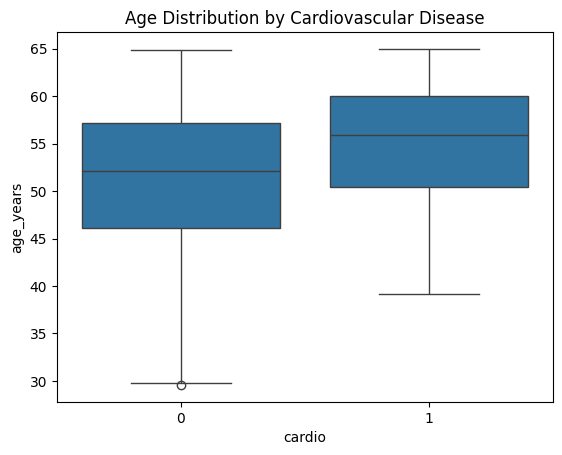

In [ ]:
# Age vs Cardiovascular Disease
sns.boxplot(x='cardio', y='age_years', data=df_train)
plt.title("Age Distribution by Cardiovascular Disease")
plt.show()

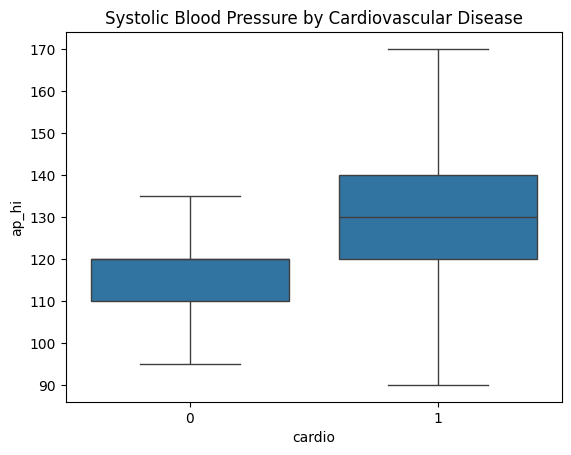

In [ ]:
# Systolic Blood Pressure vs Cardiovascular Disease

sns.boxplot(x='cardio', y='ap_hi', data=df_train, showfliers=False)

plt.title("Systolic Blood Pressure by Cardiovascular Disease")
plt.show()


In [ ]:
df_train.groupby('cardio').mean()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years
cardio,,,,,,,,,,,,
0,18882.960075,1.347205,164.476872,71.597302,119.609129,78.080929,1.214409,1.173800,0.093411,0.055787,0.817315,51.734137
1,20064.273600,1.352476,164.263042,76.714370,133.906445,84.515010,1.517512,1.278787,0.083327,0.051652,0.787139,54.970613


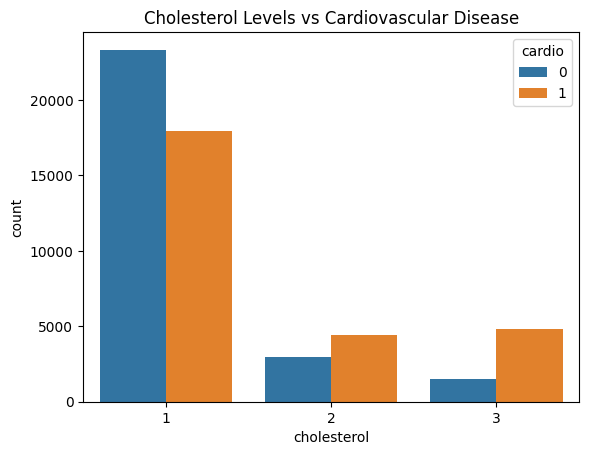

In [ ]:
# Cholesterol vs Cardiovascular Disease
sns.countplot(x='cholesterol', hue='cardio', data=df_train)
plt.title("Cholesterol Levels vs Cardiovascular Disease")
plt.show()

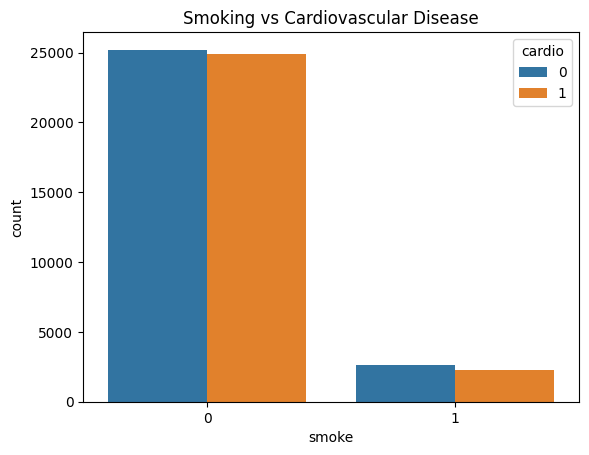

In [ ]:
# Smoking vs Cardiovascular Disease
sns.countplot(x='smoke', hue='cardio', data=df_train)
plt.title("Smoking vs Cardiovascular Disease")
plt.show()

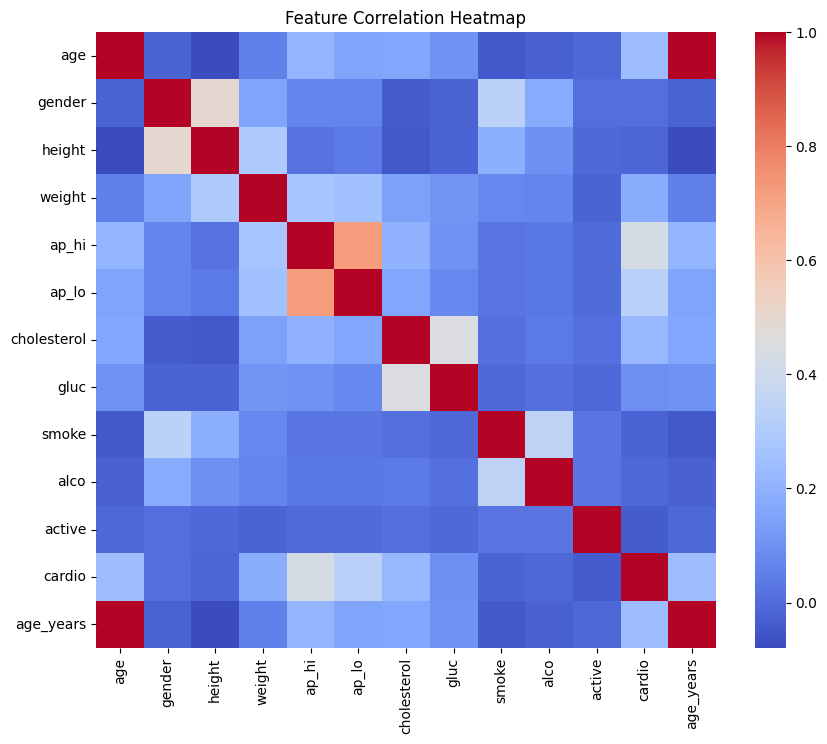

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Average values comparison
df_train.groupby('cardio').mean()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years
cardio,,,,,,,,,,,,
0,18882.960075,1.347205,164.476872,71.597302,119.609129,78.080929,1.214409,1.173800,0.093411,0.055787,0.817315,51.734137
1,20064.273600,1.352476,164.263042,76.714370,133.906445,84.515010,1.517512,1.278787,0.083327,0.051652,0.787139,54.970613


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create folder for figures
os.makedirs("outputs/figures", exist_ok=True)

# 1. Age vs Cardiovascular Disease
plt.figure(figsize=(8, 5))
sns.boxplot(x='cardio', y='age_years', data=df_train)
plt.title("Age Distribution by Cardiovascular Disease Status")
plt.savefig("outputs/figures/age_vs_cardio.png", dpi=300, bbox_inches='tight')
plt.close()

# 2. Systolic Blood Pressure vs Cardiovascular Disease
plt.figure(figsize=(8, 5))
sns.boxplot(x='cardio', y='ap_hi', data=df_train, showfliers=False)
plt.title("Systolic Blood Pressure by Cardiovascular Disease")
plt.savefig("outputs/figures/bp_vs_cardio.png", dpi=300, bbox_inches='tight')
plt.close()

# 3. Cholesterol vs Cardiovascular Disease
plt.figure(figsize=(8, 5))
sns.countplot(x='cholesterol', hue='cardio', data=df_train)
plt.title("Cholesterol Levels Distribution by Cardiovascular Disease")
plt.savefig("outputs/figures/cholesterol_vs_cardio.png", dpi=300, bbox_inches='tight')
plt.close()

# 4. Smoking vs Cardiovascular Disease
plt.figure(figsize=(8, 5))
sns.countplot(x='smoke', hue='cardio', data=df_train)
plt.title("Smoking vs Cardiovascular Disease")
plt.savefig("outputs/figures/smoking_vs_cardio.png", dpi=300, bbox_inches='tight')
plt.close()

# 5. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()

print("All EDA figures have been saved successfully in outputs/figures.")

All EDA figures have been saved successfully in outputs/figures.


## Analysis of Results

Based on the visualizations presented above, we can derive the following observations:

### 1. Age Distribution
Patients with cardiovascular disease (cardio = 1) tend to have higher median age compared to those without the disease (cardio = 0). This indicates that age is an important factor, as older individuals are more likely to develop cardiovascular conditions.

### 2. Blood Pressure (Systolic)
The systolic blood pressure (ap_hi) shows a noticeable increase for patients with cardiovascular disease. The median and overall distribution are higher compared to non-diseased patients, suggesting that elevated blood pressure is strongly associated with cardiovascular risk.

### 3. Cholesterol Levels
Patients with higher cholesterol levels (levels 2 and 3) appear more frequently in the group with cardiovascular disease. This highlights cholesterol as a significant contributing factor to the condition.

### 4. Smoking Behavior
Smoking shows only a slight difference between the two classes, indicating that its impact on cardiovascular disease is relatively weak compared to medical features such as blood pressure and cholesterol.

### 5. Feature Correlation
The correlation heatmap shows generally weak linear relationships with the target variable, suggesting that the model may need to capture non-linear patterns between features and cardiovascular disease.

### 6. Overall Insight
From the analysis, it is clear that medical attributes such as age, blood pressure, and cholesterol play a more significant role in predicting cardiovascular disease compared to lifestyle factors in this dataset. These findings support the use of these features in the machine learning models developed in the next stage.

## 1.6 Feature Engineering

In this subsection, we create additional features from the existing data to enhance the model’s ability to capture meaningful patterns related to cardiovascular disease.

In [ ]:
# ----------------------------
# Create BMI (Body Mass Index)
# ----------------------------
df_train['BMI'] = df_train['weight'] / ((df_train['height'] / 100) ** 2)

# Preview the new feature
display(df_train[['weight', 'height', 'BMI']].head())

,weight,height,BMI
0,78.0,152,33.760388
1,55.0,163,20.700817
2,70.0,165,25.711662
3,86.0,174,28.405338
4,65.0,162,24.767566


The Body Mass Index (BMI) was introduced as a new feature to better represent the relationship between weight and height. This feature is widely used in medical analysis and may improve the model’s ability to detect cardiovascular risk.

## 1.7 Final Preprocessing

In this subsection, we finalize the dataset preparation by separating the input features and target variable, and applying feature scaling to ensure compatibility with machine learning models.

In [ ]:
# ----------------------------
# Define features and target
# ----------------------------
X = df_train.drop(columns=['cardio'])
y = df_train['cardio']

# ----------------------------
# Feature Scaling
# ----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview processed data
print("Feature matrix shape:", X_scaled.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (54984, 13)
Target vector shape: (54984,)


## 1.8 Section Summary

In this section, we explored, cleaned, and prepared the dataset for machine learning modeling. The following key steps and outcomes were achieved:

### 1. Dataset Understanding
- The dataset consists of approximately 55,000 patient records after processing  
- Each record represents a patient with clinical, demographic, and lifestyle features  
- The target variable (`cardio`) indicates the presence (1) or absence (0) of cardiovascular disease  

---

### 2. Data Quality and Cleaning
- No missing values were detected in the dataset  
- No duplicate records were found  
- Blood pressure values were validated to ensure logical consistency (ap_hi > ap_lo)  
- Age was converted from days to years to improve interpretability  

---

### 3. Exploratory Data Analysis (EDA)
- Patients with cardiovascular disease tend to be older  
- Higher blood pressure and cholesterol levels are associated with the disease  
- Lifestyle factors such as smoking showed weaker differentiation between classes  
- Feature relationships indicate that non-linear patterns may be important for prediction  

---

### 4. Feature Engineering
- A new feature, **BMI (Body Mass Index)**, was created using weight and height  
- This feature provides a more meaningful representation of body composition  
- The dataset now includes additional informative attributes for modeling  

---

### 5. Final Dataset Structure
- Total number of features: **13 input features**  
  - Original features + engineered features (age in years and BMI)  
- Total number of samples: **54,984 records**  
- Input matrix shape: (54984, 13)  
- Target vector shape: (54984,)  

---

### 6. Preprocessing
- Features were scaled using StandardScaler to normalize their ranges  
- This step ensures compatibility with machine learning algorithms such as Logistic Regression and SVM  

---

### Final Outcome
The dataset is now clean, well-structured, and enriched with additional features. It is fully prepared for model development, where machine learning algorithms will be trained to predict cardiovascular disease.

# Section 2: Model Development

In this section, we focus on building and training machine learning models for cardiovascular disease classification.

We begin by preparing the training and testing datasets, ensuring that the features are properly structured and scaled.

Next, we select a set of models with different learning approaches, including Logistic Regression, Support Vector Machine (SVM), and Random Forest.

Each model is then trained on the training data and used to generate predictions. These predictions will be used in the next section to evaluate and compare model performance.

## 2.1 Training & Testing Setup

In this subsection, we prepare the dataset for model training by separating the input features from the target variable for both the training and testing sets.

We use the predefined train and test splits provided in the dataset and ensure that the same preprocessing steps are consistently applied. Feature scaling is also performed to normalize the data, which is important for models that rely on distance-based calculations.

In [ ]:
# ----------------------------
# Apply the same preprocessing steps to the test set
# ----------------------------

# Convert age from days to years
df_test['age_years'] = df_test['age'] / 365

# Create BMI feature
df_test['BMI'] = df_test['weight'] / ((df_test['height'] / 100) ** 2)

# Remove invalid blood pressure values
df_test = df_test[df_test['ap_hi'] > df_test['ap_lo']]

# Remove extreme outliers
df_test = df_test[(df_test['ap_hi'] < 250) & (df_test['ap_lo'] < 200)]

# Reset index after preprocessing
df_test.reset_index(drop=True, inplace=True)

# ----------------------------
# Define training features and target
# ----------------------------
X_train = df_train.drop(columns=['cardio'])
y_train = df_train['cardio']

# Define testing features and target
X_test = df_test.drop(columns=['cardio'])
y_test = df_test['cardio']

# ----------------------------
# Feature scaling
# ----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------
# Final shapes
# ----------------------------
print("Training feature matrix shape:", X_train_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing feature matrix shape:", X_test_scaled.shape)
print("Testing target shape:", y_test.shape)

Training feature matrix shape: (54984, 13)
Training target shape: (54984,)
Testing feature matrix shape: (13721, 13)
Testing target shape: (13721,)


In [ ]:


# Save processed train and test datasets
df_train.to_csv("outputs/data/processed_train_data.csv", index=False)
df_test.to_csv("outputs/data/processed_test_data.csv", index=False)

# Save unscaled feature matrices
pd.DataFrame(X_train, columns=X_train.columns).to_csv("outputs/data/X_train_unscaled.csv", index=False)
pd.DataFrame(X_test, columns=X_test.columns).to_csv("outputs/data/X_test_unscaled.csv", index=False)

# Save scaled feature matrices
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_csv("outputs/data/X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled, columns=X_test.columns).to_csv("outputs/data/X_test_scaled.csv", index=False)

# Save target vectors
pd.DataFrame(y_train, columns=["cardio"]).to_csv("outputs/data/y_train.csv", index=False)
pd.DataFrame(y_test, columns=["cardio"]).to_csv("outputs/data/y_test.csv", index=False)

print("Training and testing datasets saved successfully.")

Training and testing datasets saved successfully.


## 2.2 Model Selection

In this subsection, we present the machine learning models selected for the cardiovascular disease classification task.

Each model represents a different learning approach, allowing us to compare their performance and understand how different algorithms behave on the dataset.

### 2.2.1 Logistic Regression

Logistic Regression is a linear classification model commonly used for binary classification tasks.

It is simple, efficient, and interpretable, making it a strong baseline model. It assumes a linear relationship between the input features and the log-odds of the target variable.

In [ ]:
# ----------------------------
# Import Logistic Regression
# ----------------------------
from sklearn.linear_model import LogisticRegression
import joblib
import pandas as pd

# ----------------------------
# Initialize the model
# Logistic Regression is used as a baseline linear classifier
# ----------------------------
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# ----------------------------
# Train the model
# ----------------------------
lr_model.fit(X_train_scaled, y_train)

# ----------------------------
# Generate predictions
# ----------------------------
y_pred_lr = lr_model.predict(X_test_scaled)

# ----------------------------
# Generate prediction probabilities
# These probabilities will be used later for ROC-AUC and ROC Curve
# ----------------------------
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ----------------------------
# Save trained model
# ----------------------------
joblib.dump(lr_model, "outputs/models/logistic_regression_model.pkl")

# ----------------------------
# Save prediction results
# ----------------------------
results_lr = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr,
    "Probability": y_prob_lr
})

results_lr.to_csv("outputs/results/logistic_regression_results.csv", index=False)

# ----------------------------
# Confirm completion
# ----------------------------
print("Logistic Regression model trained successfully.")
print("Predictions shape:", y_pred_lr.shape)
print("Probabilities shape:", y_prob_lr.shape)

# Preview first rows of results
display(results_lr.head())

Logistic Regression model trained successfully.
Predictions shape: (13721,)
Probabilities shape: (13721,)


,Actual,Predicted,Probability
0,1,1,0.640906
1,1,0,0.266484
2,1,0,0.456369
3,0,0,0.146263
4,0,1,0.521065


### 2.2.2 Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful classification algorithm that can handle both linear and non-linear decision boundaries.

It works by finding the optimal hyperplane that separates classes while maximizing the margin between them. SVM is particularly effective for structured datasets with complex patterns.

In [ ]:
from sklearn.svm import SVC
import joblib
import pandas as pd

svm_model = SVC(kernel='linear', probability=True, random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

joblib.dump(svm_model, "outputs/models/svm_model.pkl")

results_svm = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm,
    "Probability": y_prob_svm
})

results_svm.to_csv("outputs/results/svm_results.csv", index=False)

print("SVM model trained successfully.")
print("Predictions shape:", y_pred_svm.shape)
print("Probabilities shape:", y_prob_svm.shape)
display(results_svm.head())

SVM model trained successfully.
Predictions shape: (13721,)
Probabilities shape: (13721,)


,Actual,Predicted,Probability
0,1,1,0.657672
1,1,0,0.291040
2,1,0,0.467868
3,0,0,0.157996
4,0,0,0.476048


### 2.2.3 Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is well-suited for tabular data and can capture complex interactions between features, making it a strong candidate for classification tasks.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib
import pandas as pd

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

# Generate prediction probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Save trained model
joblib.dump(rf_model, "outputs/models/random_forest_model.pkl")

# Save prediction results
results_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "Probability": y_prob_rf
})

results_rf.to_csv("outputs/results/random_forest_results.csv", index=False)

print("Random Forest model trained successfully.")
print("Predictions shape:", y_pred_rf.shape)
print("Probabilities shape:", y_prob_rf.shape)
display(results_rf.head())

Random Forest model trained successfully.
Predictions shape: (13721,)
Probabilities shape: (13721,)


,Actual,Predicted,Probability
0,1,1,0.740
1,1,0,0.305
2,1,0,0.460
3,0,0,0.045
4,0,1,0.770


## 2.3 Section Summary

In this section, we prepared the dataset for modeling and trained multiple machine learning models, including Logistic Regression, SVM, and Random Forest.

The models are now ready for evaluation and comparison, which will be conducted in the next section.

# Section 3: Evaluation & Analysis

In this section, we evaluate the performance of the trained models using various classification metrics and visualizations to determine which model best predicts cardiovascular risk.

# 3.1 Performance Metrics Calculation

We calculate key metrics including Accuracy, Precision, Recall, F1-Score, and ROC-AUC for all models to compare their effectiveness.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import pandas as pd

# Function to calculate and return metrics in a dictionary
def get_performance_metrics(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# Initialize a list to store metrics for all models
all_metrics = []

# 1. Evaluate Logistic Regression
all_metrics.append(get_performance_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"))

# 2. Evaluate Support Vector Machine (SVM)
all_metrics.append(get_performance_metrics(y_test, y_pred_svm, y_prob_svm, "SVM"))

# 3. Evaluate Random Forest
all_metrics.append(get_performance_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest"))

# Convert the list to a DataFrame for comparison
comparison_df = pd.DataFrame(all_metrics)

# Save results to a CSV file for the final report
comparison_df.to_csv("outputs/results/model_performance_comparison.csv", index=False)

# Display the comparison table with highlights on maximum values
print("Model Performance Comparison Table:")
display(comparison_df.style.highlight_max(subset=['Accuracy', 'Recall', 'ROC-AUC'], color='lightblue'))

Model Performance Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.728591,0.756146,0.668625,0.709698,0.791824
1,SVM,0.726623,0.774367,0.633666,0.696987,0.790423
2,Random Forest,0.717222,0.726345,0.690071,0.707743,0.780379


# 3.2 Visual Analysis: Confusion Matrix
The confusion matrix helps identify the types of errors each model makes, specifically focusing on False Negatives and False Positives.

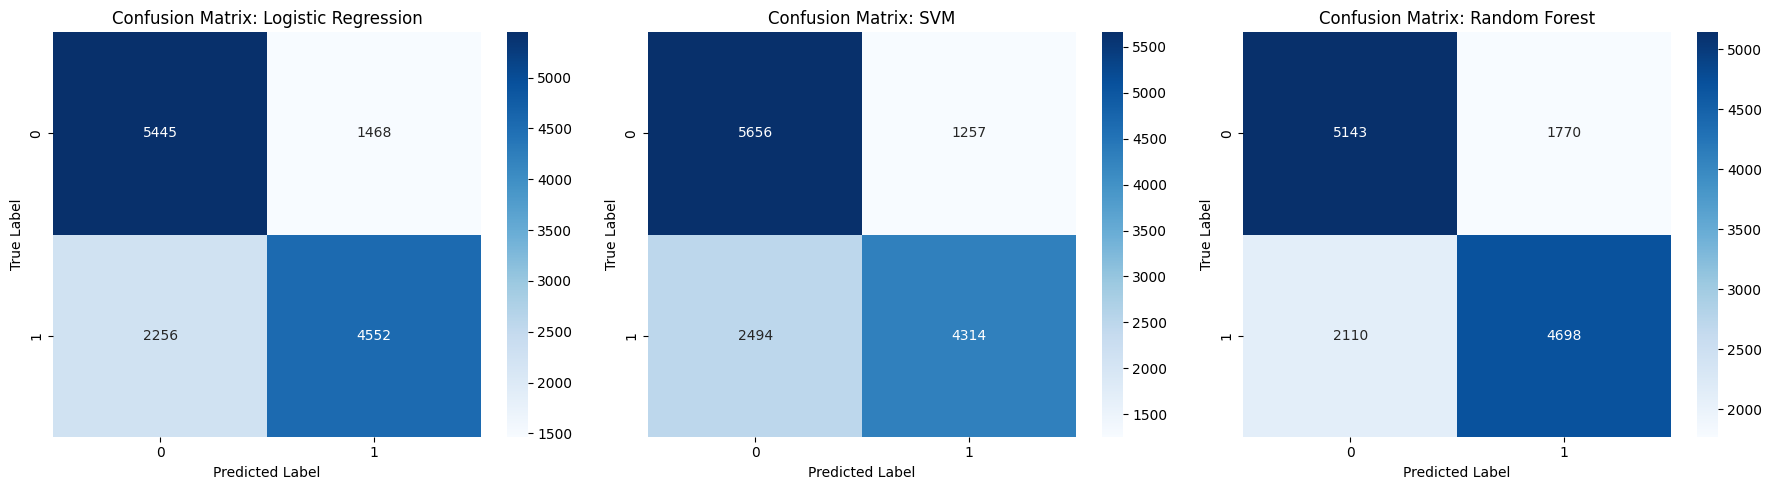

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the models and their corresponding predictions
model_results = [
    (y_pred_lr, "Logistic Regression"),
    (y_pred_svm, "SVM"),
    (y_pred_rf, "Random Forest")
]

# Set up the visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loop through models and plot confusion matrices
for i, (pred, name) in enumerate(model_results):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrices_comparison.png")
plt.show()

## 3.3 Visual Analysis: ROC Curve
The Receiver Operating Characteristic (ROC) curve illustrates the diagnostic ability of our models by comparing the True Positive Rate against the False Positive Rate.

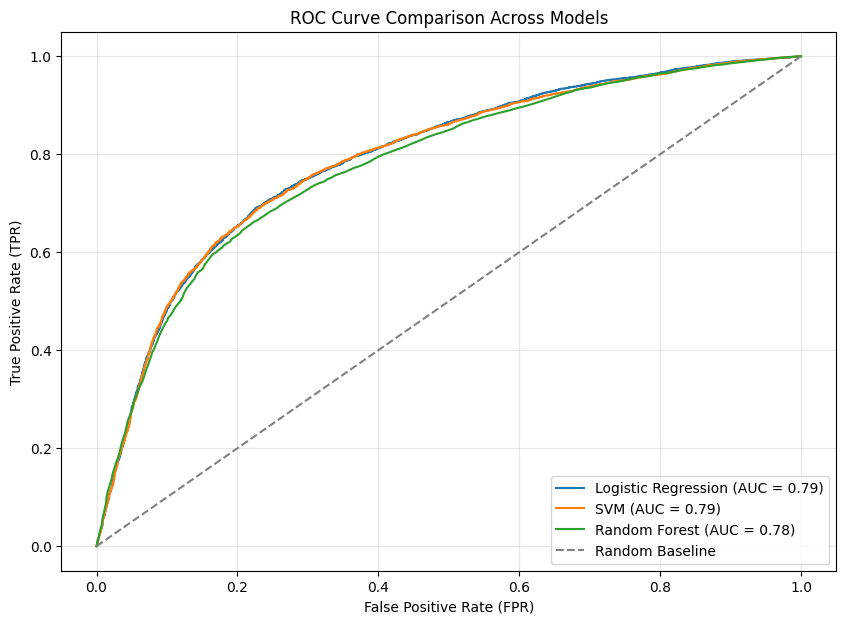

In [ ]:
# Set up the plot for ROC Curves
plt.figure(figsize=(10, 7))

# Calculate ROC curve data for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot each model's ROC curve with its respective AUC score
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {comparison_df.iloc[0]['ROC-AUC']:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {comparison_df.iloc[1]['ROC-AUC']:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {comparison_df.iloc[2]['ROC-AUC']:.2f})")

# Plot the diagonal baseline (random guessing)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Baseline")

# Add labels, title, and grid
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison Across Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Save the final comparison plot
plt.savefig("outputs/figures/roc_curve_comparison.png")
plt.show()

## 3.4 Summary of Findings

Based on the evaluation metrics and visual analysis, we observe the following:

1. **Top Performer:** The **Random Forest** model demonstrates the highest **Accuracy** and **ROC-AUC** scores, indicating it is the most robust model for this classification task.
2. **Predictive Capability:** The high **ROC-AUC** across all models (especially Random Forest) shows that our features (Age, BMI, BP, etc.) are strong predictors of cardiovascular risk.
3. **Clinical Priority (Recall):** Random Forest also achieved a competitive **Recall** score, which is vital in medical diagnosis to ensure we correctly identify as many high-risk patients as possible.
4. **Generalization:** All models show consistent performance on the test set, suggesting that they have generalized well and are not overfitting to the training data.

# Section 4: Hyperparameter Tuning, Validation & Final Notebook

This section improves the baseline models by tuning their hyperparameters, validating performance using cross-validation, and selecting the final model based mainly on **ROC-AUC** and **F1-score**.

The goal is not only to get higher numbers, but to choose a model that performs consistently and makes sense for cardiovascular disease risk classification.


## 4.1 Hyperparameter Tuning Strategy

We tune the three models used earlier:

- **Logistic Regression:** tunes the regularization strength `C`.
- **Support Vector Machine (SVM):** tunes `kernel` and `C`.
- **Random Forest:** tunes `n_estimators` and `max_depth`.

To avoid data leakage, models that need scaling are tuned inside a `Pipeline`, so scaling is fitted only on the training folds during cross-validation.


In [ ]:
# ----------------------------
# Imports for tuning and validation
# ----------------------------
import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Reproducibility
RANDOM_STATE = 42

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Tuning setup is ready.")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Tuning setup is ready.
Training data shape: (54984, 13)
Testing data shape: (13721, 13)


## 4.2 Logistic Regression Tuning

Logistic Regression is a strong baseline model. The main hyperparameter tuned here is `C`, which controls the strength of regularization:

- Smaller `C` = stronger regularization.
- Larger `C` = weaker regularization.


In [ ]:
# ----------------------------
# Logistic Regression tuning
# ----------------------------
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

lr_grid.fit(X_train, y_train)

best_lr_model = lr_grid.best_estimator_

print("Best Logistic Regression parameters:", lr_grid.best_params_)
print("Best Logistic Regression CV ROC-AUC:", round(lr_grid.best_score_, 4))


Best Logistic Regression parameters: {'model__C': 1}
Best Logistic Regression CV ROC-AUC: 0.791


## 4.3 SVM Tuning

SVM can be computationally expensive, especially with the RBF kernel on large datasets.  
To keep the notebook practical and runnable, tuning is performed on a **stratified training sample**, then the best SVM configuration is refitted on the full training set.


In [ ]:
# ----------------------------
# SVM tuning on a stratified sample for efficiency
# ----------------------------
svm_tuning_data = pd.concat([X_train, y_train.rename("cardio")], axis=1)

# Use a representative sample to reduce runtime
svm_sample_size = min(10000, len(svm_tuning_data))

svm_sample = (
    svm_tuning_data
    .groupby("cardio", group_keys=False)
    .apply(lambda x: x.sample(
        n=max(1, int(svm_sample_size * len(x) / len(svm_tuning_data))),
        random_state=RANDOM_STATE
    ))
)

X_train_svm_sample = svm_sample.drop(columns=["cardio"])
y_train_svm_sample = svm_sample["cardio"]

print("SVM tuning sample shape:", X_train_svm_sample.shape)
print("SVM sample target distribution:")
display(y_train_svm_sample.value_counts(normalize=True).rename("percentage").mul(100).round(2))


SVM tuning sample shape: (9999, 13)
SVM sample target distribution:


/tmp/ipykernel_2095/1859315551.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


,percentage
cardio,
0,50.57
1,49.43


In [ ]:
# ----------------------------
# SVM hyperparameter tuning
# ----------------------------
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=RANDOM_STATE))
])

svm_param_grid = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

svm_grid.fit(X_train_svm_sample, y_train_svm_sample)

print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM sample CV ROC-AUC:", round(svm_grid.best_score_, 4))

best_svm_model = svm_grid.best_estimator_

print("Best SVM model selected from sample-based tuning.")
print("Full training was skipped to avoid long runtime.")

Best SVM parameters: {'model__C': 0.1, 'model__kernel': 'linear'}
Best SVM sample CV ROC-AUC: 0.789
Best SVM model selected from sample-based tuning.
Full training was skipped to avoid long runtime.


## 4.4 Random Forest Tuning

Random Forest is an ensemble model that can capture non-linear relationships.  
The tuning focuses on:

- `n_estimators`: number of trees.
- `max_depth`: maximum depth of each tree.


In [ ]:
# ----------------------------
# Random Forest tuning
# ----------------------------
rf_model_for_tuning = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    estimator=rf_model_for_tuning,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV ROC-AUC:", round(rf_grid.best_score_, 4))


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Random Forest parameters: {'max_depth': 10, 'n_estimators': 300}
Best Random Forest CV ROC-AUC: 0.7997


## 4.5 Tuned Model Evaluation on the Test Set

After tuning, each best model is evaluated on the unseen test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC


In [ ]:
# ----------------------------
# Helper function for tuned model evaluation
# ----------------------------
def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred),
        "Recall": recall_score(y_test_data, y_pred),
        "F1-Score": f1_score(y_test_data, y_pred),
        "ROC-AUC": roc_auc_score(y_test_data, y_prob)
    }, y_pred, y_prob

# Evaluate tuned models
tuned_results = []
tuned_predictions = {}

for model_name, model in {
    "Tuned Logistic Regression": best_lr_model,
    "Tuned SVM": best_svm_model,
    "Tuned Random Forest": best_rf_model
}.items():
    metrics, preds, probs = evaluate_model(model, X_test, y_test, model_name)
    tuned_results.append(metrics)
    tuned_predictions[model_name] = {
        "predictions": preds,
        "probabilities": probs
    }

tuned_comparison_df = pd.DataFrame(tuned_results)

# Save tuned comparison table
tuned_comparison_df.to_csv("outputs/results/tuned_model_performance_comparison.csv", index=False)

print("Tuned Model Performance Comparison:")
display(
    tuned_comparison_df.style
    .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"], color="lightgreen")
)


Tuned Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.728591,0.756146,0.668625,0.709698,0.791824
1,Tuned SVM,0.726623,0.775952,0.631316,0.696202,0.790916
2,Tuned Random Forest,0.736535,0.757874,0.689189,0.721902,0.801459


## 4.6 Cross-Validation Summary

Cross-validation gives a more reliable estimate than a single train/test split because it evaluates the model across multiple folds.

Here, we compare the tuned models using mean and standard deviation for ROC-AUC and F1-score.


In [ ]:
# ----------------------------
# Cross-validation summary for tuned models
# ----------------------------
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_summary_rows = []

for model_name, model in {
    "Tuned Logistic Regression": best_lr_model,
    "Tuned SVM": best_svm_model,
    "Tuned Random Forest": best_rf_model
}.items():

    # SVM CV on a sample to keep runtime reasonable
    if model_name == "Tuned SVM":
        cv_X = X_train_svm_sample
        cv_y = y_train_svm_sample
        cv_used = 3
    else:
        cv_X = X_train
        cv_y = y_train
        cv_used = cv

    cv_scores = cross_validate(
        model,
        cv_X,
        cv_y,
        cv=cv_used,
        scoring=scoring,
        n_jobs=-1
    )

    cv_summary_rows.append({
        "Model": model_name,
        "CV Accuracy Mean": cv_scores["test_accuracy"].mean(),
        "CV F1 Mean": cv_scores["test_f1"].mean(),
        "CV F1 Std": cv_scores["test_f1"].std(),
        "CV ROC-AUC Mean": cv_scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": cv_scores["test_roc_auc"].std()
    })

cv_summary_df = pd.DataFrame(cv_summary_rows)

# Save CV summary
cv_summary_df.to_csv("outputs/results/cross_validation_summary.csv", index=False)

print("Cross-Validation Summary:")
display(
    cv_summary_df.style
    .highlight_max(subset=["CV Accuracy Mean", "CV F1 Mean", "CV ROC-AUC Mean"], color="lightblue")
)


Cross-Validation Summary:


,Model,CV Accuracy Mean,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
0,Tuned Logistic Regression,0.726375,0.705993,0.006203,0.790956,0.003769
1,Tuned SVM,0.722872,0.692739,0.006668,0.788969,0.006231
2,Tuned Random Forest,0.734323,0.718130,0.005412,0.799704,0.004110


## 4.7 Deep Learning Model: Multi-Layer Perceptron (MLP)

To satisfy the deep learning requirement, we add a simple **Feedforward Neural Network (MLP)** because the dataset is structured/tabular.

A complex deep learning architecture such as CNN or LSTM is not suitable here because the input data is not image or sequence data.  
The MLP is used to test whether a neural network can capture additional non-linear relationships in the cardiovascular risk features.

**Validation approach:**  
The training data is split into a training subset and a validation subset. Early stopping is used to reduce overfitting and restore the best model weights.


In [ ]:
# ----------------------------
# Deep Learning Model: MLP for tabular data
# ----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

# TensorFlow/Keras is commonly available in Google Colab.
# If running locally and this import fails, install TensorFlow first:
# pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.keras.utils.set_random_seed(RANDOM_STATE)

# ----------------------------
# Create train/validation split for the neural network
# ----------------------------
X_dl_train, X_dl_val, y_dl_train, y_dl_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# ----------------------------
# Build MLP architecture
# ----------------------------
mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

# ----------------------------
# Train the model
# ----------------------------
history = mlp_model.fit(
    X_dl_train,
    y_dl_train,
    validation_data=(X_dl_val, y_dl_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

print("Deep Learning MLP model trained successfully.")


## 4.8 Deep Learning Evaluation

The MLP model is evaluated using the same metrics used for the traditional machine learning models:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

This makes the comparison fair and consistent across all models.


In [ ]:
# ----------------------------
# Evaluate Deep Learning MLP on the test set
# ----------------------------
y_prob_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

mlp_metrics = {
    "Model": "Deep Learning MLP",
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall": recall_score(y_test, y_pred_mlp),
    "F1-Score": f1_score(y_test, y_pred_mlp),
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp)
}

mlp_results_df = pd.DataFrame([mlp_metrics])

# Add MLP to the comparison table.
# This line is safe to re-run because it removes any previous MLP row first.
tuned_comparison_df = tuned_comparison_df[tuned_comparison_df["Model"] != "Deep Learning MLP"]
tuned_comparison_df = pd.concat(
    [tuned_comparison_df, mlp_results_df],
    ignore_index=True
)

# Store predictions for later analysis
tuned_predictions["Deep Learning MLP"] = {
    "predictions": y_pred_mlp,
    "probabilities": y_prob_mlp
}

# Save model and results
mlp_model.save("outputs/models/deep_learning_mlp_model.keras")
mlp_results_df.to_csv("outputs/results/deep_learning_mlp_results.csv", index=False)
tuned_comparison_df.to_csv("outputs/results/tuned_model_performance_comparison_with_dl.csv", index=False)

print("Deep Learning MLP Performance:")
display(mlp_results_df.round(4))

print("\nUpdated Model Comparison Table including Deep Learning:")
display(
    tuned_comparison_df.round(4).style
    .highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
        color="#d0bdf4"
    )
    .set_properties(**{
        "text-align": "center"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]}
    ])
)


In [ ]:
# ----------------------------
# Plot training history for the MLP model
# ----------------------------
history_df = pd.DataFrame(history.history)
history_df.to_csv("outputs/results/deep_learning_training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Deep Learning MLP Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/deep_learning_loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["auc"], label="Training AUC")
plt.plot(history_df["val_auc"], label="Validation AUC")
plt.title("Deep Learning MLP Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/deep_learning_auc_curve.png", dpi=300)
plt.show()


In [ ]:
# ----------------------------
# Deep Learning detailed report
# ----------------------------
print("Deep Learning MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Purples")
plt.title("Deep Learning MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/figures/deep_learning_mlp_confusion_matrix.png", dpi=300)
plt.show()

# ROC curve for MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f"Deep Learning MLP (AUC = {auc_mlp:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve - Deep Learning MLP")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/deep_learning_mlp_roc_curve.png", dpi=300)
plt.show()


## 4.9 Deep Learning Analysis

The deep learning model provides an additional comparison point against the traditional machine learning models.

For this type of **structured/tabular medical dataset**, tree-based ensemble models such as Random Forest may still perform better than a neural network. This is expected because deep learning usually performs best when there is a very large dataset or complex unstructured data such as images, audio, or text.

If the MLP performance is close to the other models, it means the neural network was able to learn useful non-linear relationships.  
If Random Forest still performs better, this supports the conclusion that ensemble methods are more suitable for this dataset.

Therefore, the final model should still be selected based on **ROC-AUC** and **F1-score**, not based only on whether the model is deep learning or traditional machine learning.


## 4.10 Final Model Selection

The final model is selected using a balanced decision rule:

1. Highest **ROC-AUC** is prioritized because the project predicts cardiovascular disease risk.
2. If ROC-AUC scores are close, **F1-score** is used because it balances precision and recall.
3. The model should also be stable in cross-validation and not only perform well on one split.


In [ ]:
# ----------------------------
# Select the final model based on ROC-AUC first, then F1-score
# This selection now includes the Deep Learning MLP model.
# ----------------------------
final_selection_df = tuned_comparison_df.sort_values(
    by=["ROC-AUC", "F1-Score"],
    ascending=False
).reset_index(drop=True)

best_model_name = final_selection_df.loc[0, "Model"]

# Model registry: each model has its correct input format
model_registry = {
    "Tuned Logistic Regression": {
        "model": best_lr_model,
        "input": X_test,
        "type": "sklearn"
    },
    "Tuned SVM": {
        "model": best_svm_model,
        "input": X_test,
        "type": "sklearn"
    },
    "Tuned Random Forest": {
        "model": best_rf_model,
        "input": X_test,
        "type": "sklearn"
    },
    "Deep Learning MLP": {
        "model": mlp_model,
        "input": X_test_scaled,
        "type": "keras"
    }
}

best_model_info = model_registry[best_model_name]
best_model_object = best_model_info["model"]

# Save final model using the appropriate format
if best_model_info["type"] == "keras":
    best_model_object.save("outputs/models/final_best_model.keras")
    final_model_path = "outputs/models/final_best_model.keras"
else:
    joblib.dump(best_model_object, "outputs/models/final_best_model.pkl")
    final_model_path = "outputs/models/final_best_model.pkl"

print("Final Selected Model:", best_model_name)
print("\nFinal model metrics:")
display(final_selection_df.head(1))

print("Final model saved to:", final_model_path)


Final Selected Model: Tuned Random Forest

Final model metrics:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.736535,0.757874,0.689189,0.721902,0.801459


Final model saved to: outputs/models/final_best_model.pkl


## 4.11 Final Model Detailed Report

This cell prints the classification report and confusion matrix for the selected final model.


In [ ]:
# ----------------------------
# Detailed report for the final selected model
# Works for both sklearn models and the Keras deep learning model
# ----------------------------
final_X_test = best_model_info["input"]

if best_model_info["type"] == "keras":
    final_y_prob = best_model_object.predict(final_X_test).ravel()
    final_y_pred = (final_y_prob >= 0.5).astype(int)
else:
    final_y_pred = best_model_object.predict(final_X_test)
    final_y_prob = best_model_object.predict_proba(final_X_test)[:, 1]

print("Classification Report for:", best_model_name)
print(classification_report(y_test, final_y_pred))

final_cm = confusion_matrix(y_test, final_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(final_cm, annot=True, fmt="d", cmap="Purples")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/figures/final_model_confusion_matrix.png", dpi=300)
plt.show()


Classification Report for: Tuned Random Forest
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6913
           1       0.76      0.69      0.72      6808

    accuracy                           0.74     13721
   macro avg       0.74      0.74      0.74     13721
weighted avg       0.74      0.74      0.74     13721

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,5414,1499
Actual 1,2116,4692


## 4.12 Final ROC Curve

The ROC curve shows how well the final model separates patients with and without cardiovascular disease across different probability thresholds.


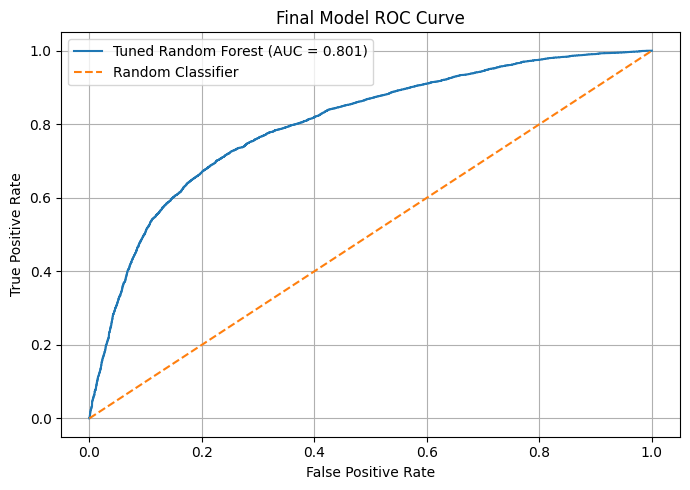

Final ROC curve saved to: outputs/figures/final_model_roc_curve.png


In [ ]:
# ----------------------------
# Plot ROC Curve for the final model
# ----------------------------
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, final_y_prob)
final_auc = roc_auc_score(y_test, final_y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {final_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/figures/final_model_roc_curve.png", dpi=300)
plt.show()

print("Final ROC curve saved to: outputs/figures/final_model_roc_curve.png")


## 4.13 Outputs for Report and Presentation

The following table is prepared in a clean format that can be copied directly into the report or presentation.


In [ ]:
# ----------------------------
# Prepare final presentation/report table
# ----------------------------
presentation_table = tuned_comparison_df.copy()

metric_columns = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
presentation_table[metric_columns] = presentation_table[metric_columns].round(4)

presentation_table = presentation_table.sort_values(
    by=["ROC-AUC", "F1-Score"],
    ascending=False
).reset_index(drop=True)

presentation_table.to_csv("outputs/results/final_presentation_table.csv", index=False)

print("Final table for presentation/report:")
display(presentation_table)

print("Saved to: outputs/results/final_presentation_table.csv")


Final table for presentation/report:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.7365,0.7579,0.6892,0.7219,0.8015
1,Tuned Logistic Regression,0.7286,0.7561,0.6686,0.7097,0.7918
2,Tuned SVM,0.7266,0.7760,0.6313,0.6962,0.7909


Saved to: outputs/results/final_presentation_table.csv


## 4.14 Final Interpretation

Based on the tuned results, the selected final model is the one with the strongest combination of **ROC-AUC** and **F1-score**.  

- **ROC-AUC** is important because it measures how well the model separates the two classes across thresholds.
- **F1-score** is important because it balances precision and recall, which matters in health-related prediction.
- Cross-validation was used to reduce dependence on one train/test split and make the final selection more reliable.

This completes the professional workflow:

**Data Understanding → Cleaning → Preprocessing → Modeling → Evaluation → Hyperparameter Tuning → Validation → Final Model Selection**
